In [1]:
import refnx
import numpy as np
import dynesty

from hogben.models.base import MagneticSLD
from hogben.models.samples import Sample
from hogben.optimise import Optimiser, optimise_parameters
from hogben.utils import Fisher
from hogben.visualise import angle_choice

from refnx.dataset import ReflectDataset
from refnx.analysis import Objective, GlobalObjective, CurveFitter
from refnx.reflect import SLD, ReflectModel, MixedReflectModel, Slab, Structure

import os.path

from hogben.simulate import SimulateReflectivity
from refnx.analysis import Parameter
# Reduce size of plots for the notebook.
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7,5)
plt.rcParams['figure.dpi'] = 100

In [36]:
sub = SLD(2.074)
D2O = SLD(6.36)
H2O = SLD(-0.56)



# Slab thicknesses
t_SiO2 = Parameter(15, 'SiO2 thickness', vary=False, bounds=(0, 60))
t_inner_hg = Parameter(15, 'Inner headgroup thickness', vary=False, bounds=(10, 30))
t_tg = Parameter(28, 'Total tailgroup thickness', vary=False, bounds=(20, 40))
t_outer_hg = Parameter(18, 'Outer headgroup thickness', vary=False, bounds=(10, 30))
t_extra = Parameter(60, 'Extramembrane domain thickness', vary=True, bounds=(10, 85))

# Volume fractions and volumes
phi_s = Parameter(0.36, 'Lipid surface coverage', vary=True,bounds=(1e-7, 1))




phi_extra = Parameter(0.8, 'Volume fraction of protein in extra domain', vary=True, bounds=(0, 1))    ######################
phi_innerhg = Parameter(0.47, 'Volume fraction solvent inner hg', vary=False, bounds=(0, 1))
phi_outerhg = Parameter(0.83, 'Volume fraction solvent outer hg', vary=True, bounds=(0, 1))## not sure we want to fit the solvation fraction, just use it as 1- other parts




V_TMD = Parameter(0.1, 'TMD Molecular volume', vary=True, bounds=(1e-7, 0.6))
V_extra = Parameter(0.1, 'Extra membrane Molecular volume', vary=True, bounds=(1e-7, 0.6))
# phi_tmd = phi_extra * (t_extra*V_TMD)/(t_tg*V_extra) #Important constraint to make the protein in tails and outside membrane same


# SLD Values
sld_TMD = Parameter(0.5, 'TMD Protein SLD', bounds=(1e-7, 2.5),vary=True)
sld_lipacyl = Parameter(-0.3, 'Lipid acyl chains tg SLD', bounds=(-1, 1),vary=False) # not the exact same representation as the paper, but correct value

# sld_acyl = phi_tmd*sld_TMD + (1-phi_tmd)*sld_lipacyl






sld_innerhg = Parameter(3, 'SLD inner hg', bounds=(1, 5), vary=False)
sld_outerhg = Parameter(3, 'SLD outer hg', bounds=(1, 5), vary=False)



def sld_extra(water_contrast = 6.36):
    # SLD of membrane in D2O = 2.9, in H2O = 1.8
    return 1.8 + (2.9 - 1.8)*(water_contrast + 0.56)/(6.36 + 0.56)


sld_extra_h = 1.8 # sld_extra(-0.56)
sld_extra_d = 2.9 # sld_extra(6.36)

sld_extra_smw = Parameter(2.2, 'SLD extramembrane in SMW', bounds=(1e-7, 5), vary=True)

sld_sio2 = Parameter(3.5, 'SLD sio2', bounds=(1e-7, 10))
sld_h2o = Parameter(-0.45, 'Contrast 1', bounds=(-0.56, 6.14))
sld_smw = Parameter(2.07, 'Contrast 2', bounds=(-0.56, 6.14))
sld_d2o = Parameter(6.14, 'Contrast 3', bounds=(-0.56, 6.14))

# Roughness
r_SiO2 = Parameter(3, 'SiO2 roughness', bounds=(1e-7, 15))
r_inner_hg = Parameter(3, 'Inner headgroup roughness', bounds=(1, 5),vary=False)
r_tg = Parameter(3, 'Total tailgroup roughness', bounds=(1, 5),vary=False)
r_outer_hg = Parameter(3, 'Outer headgroup roughness', bounds=(1, 5),vary=True)
# r_extra = Parameter(3, 'Extramembrane domain roughness', bounds=(1, 5),vary=True)

# Define slabs
SiO2 = Slab(t_SiO2,sld_sio2, r_SiO2, vfsolv=0.35)

inner_hg = Slab(t_inner_hg, sld_innerhg, r_inner_hg, vfsolv=phi_innerhg)

# tail = refnx.reflect.SLD(sld_acyl, name="Tail groups")(t_tg, r_tg, vfsolv=phi_s)

extra_d = Slab(t_extra, sld_extra_d, r_tg, vfsolv=(1-phi_extra))
extra_h = Slab(t_extra, sld_extra_h, r_tg, vfsolv=(1-phi_extra))


HeadSLDh = ((1-phi_outerhg-phi_extra)/(1-phi_outerhg))*sld_outerhg + ((phi_extra)/(1-phi_outerhg))*sld_extra_h
TailSLDh = ((1-phi_s-phi_extra)/(1-phi_s))*sld_lipacyl + ((phi_extra)/(1-phi_s))*sld_extra_h

HeadSLDd = ((1-phi_outerhg-phi_extra)/(1-phi_outerhg))*sld_outerhg + ((phi_extra)/(1-phi_outerhg))*sld_extra_d
TailSLDd = ((1-phi_s-phi_extra)/(1-phi_s))*sld_lipacyl + ((phi_extra)/(1-phi_s))*sld_extra_d




tail_h = Slab(t_tg,TailSLDh, r_tg, vfsolv=phi_s)
tail_d = Slab(t_tg,TailSLDd, r_tg, vfsolv=phi_s)
outer_hg_h = Slab(t_outer_hg, HeadSLDh, r_tg, vfsolv=phi_outerhg)
outer_hg_d = Slab(t_outer_hg, HeadSLDd, r_tg, vfsolv=phi_outerhg)

# Define reference layer
ul_thick = Parameter(50, 'Underlayer Thickness', (0, 1000))
ul_nsld = Parameter(6.92, 'Underlayer Nuclear SLD', (0.5, 8))
ul_msld = Parameter(0.5, 'Underlayer Magnetic SLD', (0, 6))
ul_thick.optimize = True
ul_nsld.optimize = True
ul_msld.optimize = True

# Magnetic reference layer
ul_slab = MagneticSLD(ul_nsld,ul_msld,thick=ul_thick, rough=2)


solv_rough = Parameter(5, 'Roughness of solvent interface', bounds=(1, 10), vary=True)

# With reference layer      
SiO2_RL = Slab(20, 4.18, 3,vfsolv=0.0) # no solvent in SiO2 if not top facing layer
SiO2 = Slab(t_SiO2, sld_sio2, r_SiO2, vfsolv=0.35)
structure_d2o_RL = sub | SiO2_RL | ul_slab | SiO2 | tail_d | outer_hg_d | extra_d | D2O(0,solv_rough)
structure_h2o_RL = sub | SiO2_RL | ul_slab |  SiO2 | tail_h | outer_hg_h | extra_h | H2O(0,solv_rough)
# structure_d2o_RL = sub | SiO2_RL | ul_slab | inner_hg | tail_d | outer_hg_d | extra_d | D2O
# structure_h2o_RL = sub | SiO2_RL | ul_slab | inner_hg | tail_h | outer_hg_h | extra_h | H2O          


structure_d2o = sub | SiO2 | inner_hg | tail_d | outer_hg_d | extra_d | D2O(0,solv_rough)
structure_h2o = sub | SiO2 | inner_hg | tail_h | outer_hg_h | extra_h | H2O(0,solv_rough)   



In [37]:
HeadSLDh.value

-2.6470588235294112

In [32]:
angle_times = [(0.7, 75, 20),
               (2.0, 75, 40)] # (Angle, Points, Time)

# structures = protein_structure(ref_layer=False)
model_1 = ReflectModel(structure_h2o_RL)
model_2 = ReflectModel(structure_d2o_RL)


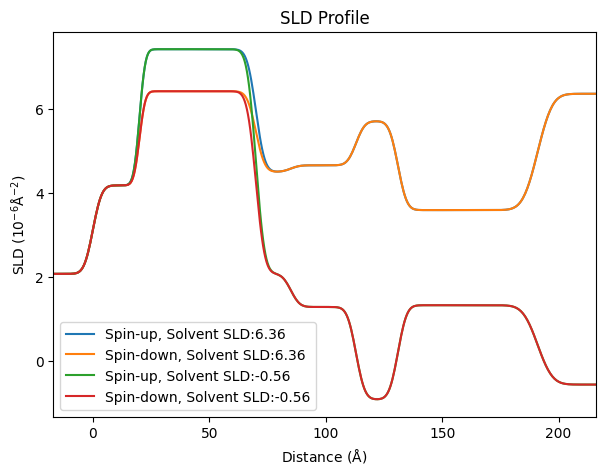

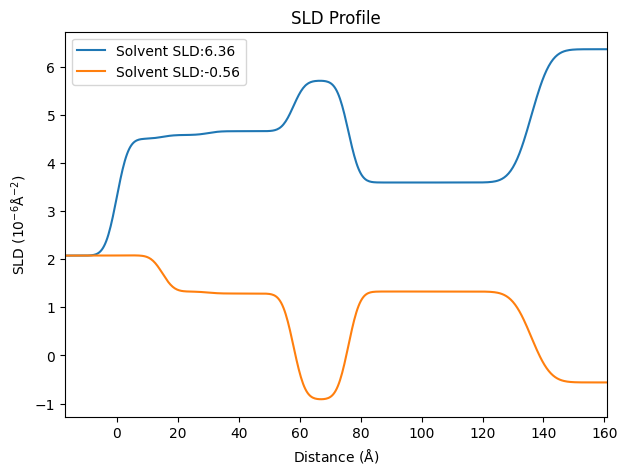

In [38]:
new_sample_ref = Sample([structure_d2o_RL, structure_h2o_RL])
new_sample_ref.polarised = True # Set to false to make it nuclear ref layer
new_sample_ref.sld_profile("test")

new_sample = Sample([structure_d2o, structure_h2o])
new_sample.sld_profile("")

In [39]:
new_sample_ref.params

[Parameter(value=5.0, name='Roughness of solvent interface', vary=True, bounds=Interval(lb=1.0, ub=10.0), constraint=None),
 Parameter(value=0.83, name='Volume fraction solvent outer hg', vary=True, bounds=Interval(lb=0.0, ub=1.0), constraint=None),
 Parameter(value=0.8, name='Volume fraction of protein in extra domain', vary=True, bounds=Interval(lb=0.0, ub=1.0), constraint=None),
 Parameter(value=0.36, name='Lipid surface coverage', vary=True, bounds=Interval(lb=1e-07, ub=1.0), constraint=None),
 Parameter(value=60.0, name='Extramembrane domain thickness', vary=True, bounds=Interval(lb=10.0, ub=85.0), constraint=None)]

The parameters with the highest information could be found at:
Underlayer Nuclear SLD: 3.46
Underlayer Thickness: 23.9
Underlayer Magnetic SLD: 6
-----------------------------------------------------------------
The minimum eigenvalue of the Fisher Information before optimization: 0.015
The minimum eigenvalue of the Fisher Information after optimization: 0.0187
The information content is 1.24 times as large after optimization.


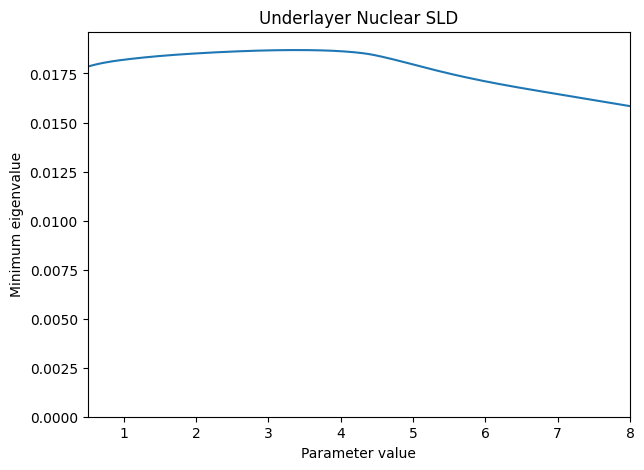

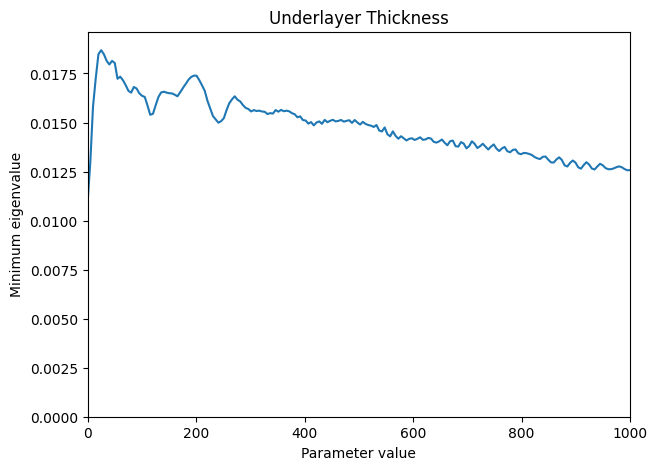

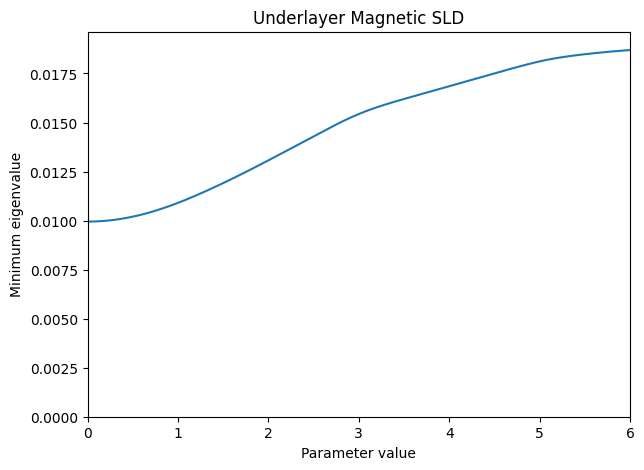

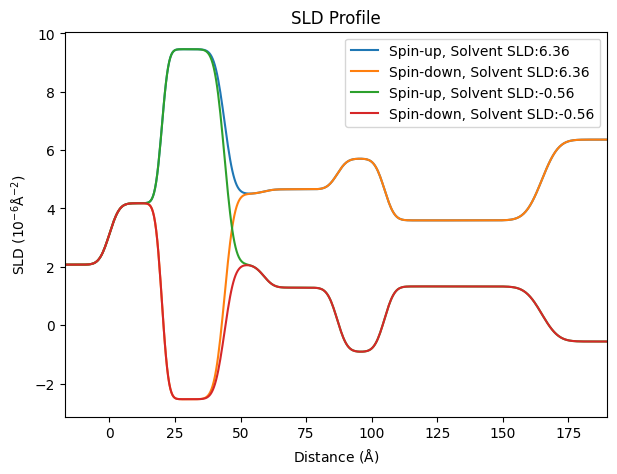

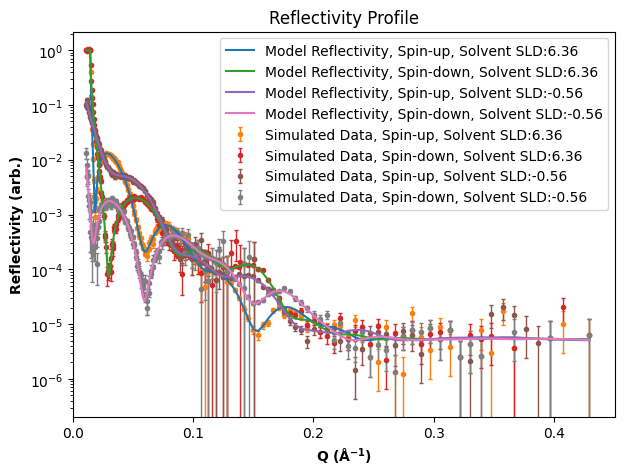

In [40]:
angle_times = [(0.7, 100, 25), (2.0, 100, 75)]
optimise_parameters(new_sample_ref, angle_times)

The parameters with the highest information could be found at:
Underlayer Magnetic SLD: 0.0813
Underlayer Nuclear SLD: 7.99
Underlayer Thickness: 187
-----------------------------------------------------------------
The minimum eigenvalue of the Fisher Information before optimization: 0.000267
The minimum eigenvalue of the Fisher Information after optimization: 0.000325
The information content is 1.21 times as large after optimization.


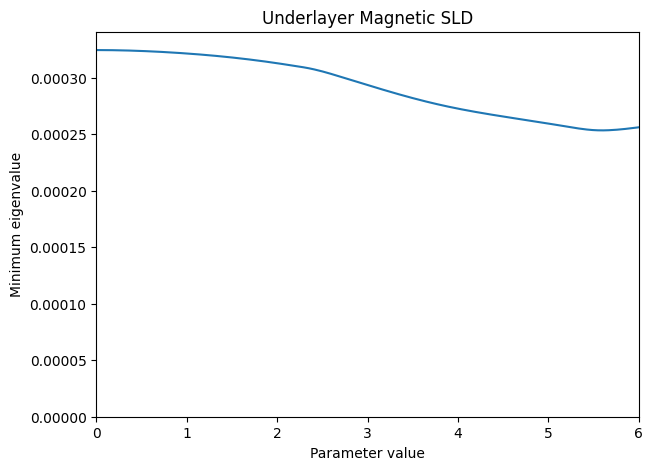

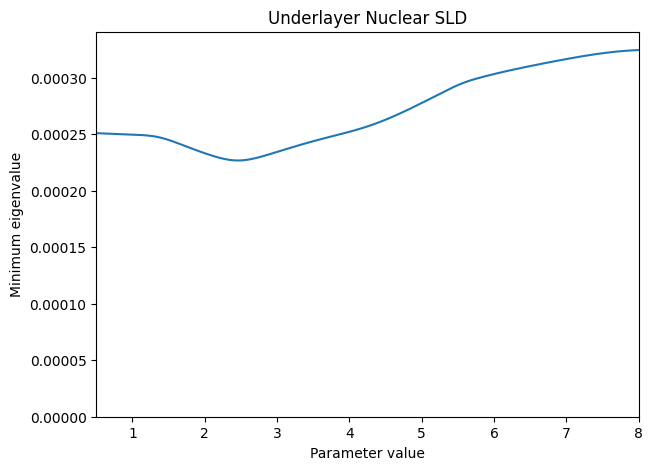

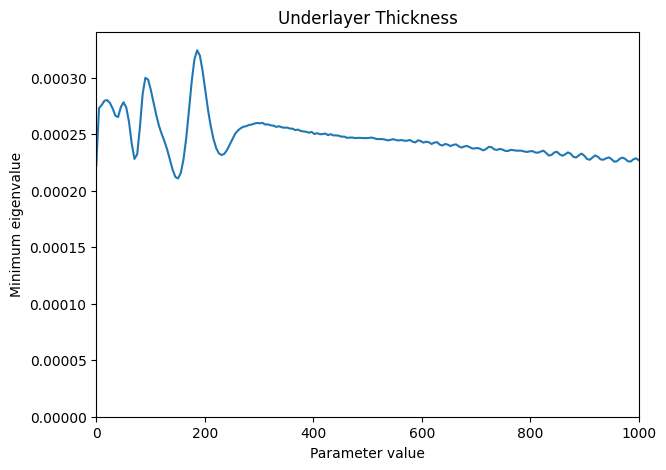

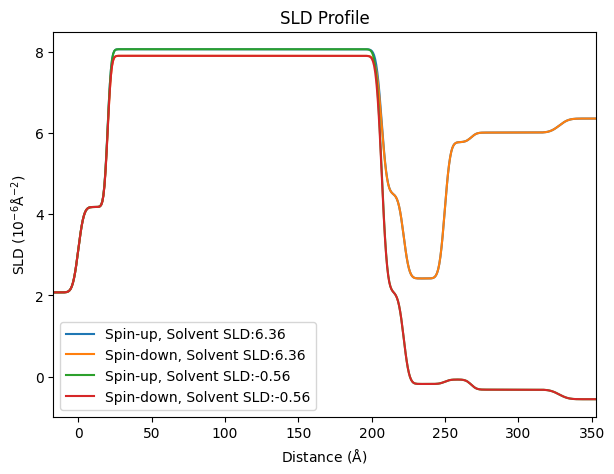

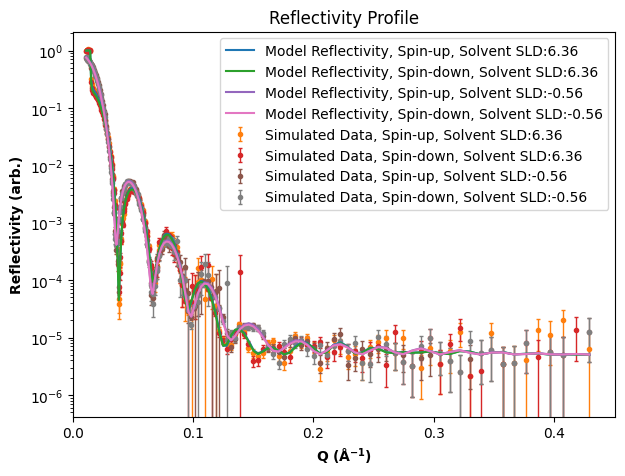

In [35]:
angle_times = [(0.7, 100, 25), (2.0, 100, 75)]
optimise_parameters(new_sample_ref, angle_times)

In [7]:
optimiser = Optimiser(new_sample_ref)
num_angles = 2 # Number of angles to optimise.

# Find the optimal angles and times using differential evolution.
angles, splits, _ = optimiser.optimise_angle_times(num_angles, angle_bounds=(0.2, 4.0), verbose=False)

# Calculate the counting times from the splits using total counting time of 100.
times = np.array(splits) * 100

print('Angles: {}'.format(np.round(angles, 2)))
print('Times: {}'.format(np.round(times, 1)))

Angles: [0.34 1.52]
Times: [72.5 27.5]


In [ ]:
angle_times_optimised = [(angles[0], 75,times[0]), (angles[1], 75,times[1])]
fisher_optimised = Fisher.from_sample(new_sample_ref, angle_times_optimised)
print(fisher_optimised.min_eigenval)

angle_times_unoptimised = [(0.7, 75, 20), (2.0, 75, 40)]
fisher_unoptimised = Fisher.from_sample(new_sample, angle_times_unoptimised)
print(fisher_unoptimised.min_eigenval)
improvement = fisher_optimised.min_eigenval/fisher_unoptimised.min_eigenval
if new_sample_ref.is_magnetic() and new_sample.polarised:
    improvement /= 4
print(f'Optimising gave an improvement of a factor {round(improvement,2)}')

In [ ]:

instrument = 'OFFSPEC' # Options are 'INTER', 'OFFSPEC', 'POLREF' or 'SURF'

# Simulate the experiment.
data_1 = SimulateReflectivity(model_1, angle_times, instrument).simulate()
data_2 = SimulateReflectivity(model_2, angle_times, instrument).simulate()
def plot_reflectivity(model, data):
    # Extract each column of the simulated `data`.
    q, r, dr, counts = data[0], data[1],  data[2], data[3]

    # Calculate the model reflectivity.
    r_model = SimulateReflectivity(model, angle_times, instrument).reflectivity(q)

    # Plot the model and simulated reflectivity against Q.
    fig = plt.figure(figsize=[9,7])
    ax = fig.add_subplot(111)

    # Model reflectivity.
    ax.plot(q, r_model, color='red', zorder=20, label='Model Reflectivity')

    # Simulated reflectivity
    ax.errorbar(q, r, dr, color='black', marker='o', ms=3, lw=0, elinewidth=1, capsize=1.5, label='Simulated Data')

    ax.set_xlabel('$\mathregular{Q\ (Å^{-1})}$', fontsize=11, weight='bold')
    ax.set_ylabel('Reflectivity (arb.)', fontsize=11, weight='bold')
    ax.set_yscale('log')
    ax.set_xlim(0, 0.3)
    ax.legend()
    plt.show()
    
plot_reflectivity(model_2, data_2)

In [ ]:
len(data_1[0:])

In [ ]:
# data_1=tuple(data_1)
# data_2=tuple(data_2)

In [ ]:
data_1 = tuple(
    tuple(col[i] for i in range(len(data_1[0]))
          if all(data_1[c][i] != 0 for c in range(len(data_1))))
    for col in data_1
)

data_2 = tuple(
    tuple(col[i] for i in range(len(data_2[0]))
          if all(data_2[c][i] != 0 for c in range(len(data_2))))
    for col in data_2
)

In [ ]:

objective_h = Objective(model_1, data_1[0:3],auxiliary_params=(phi_outerhg,phi_extra,sld_outerhg,phi_s,sld_lipacyl))
objective_d = Objective(model_2, data_2[0:3],auxiliary_params=(phi_outerhg,phi_extra,sld_outerhg,phi_s,sld_lipacyl))
global_objective = GlobalObjective([objective_h, objective_d])

In [ ]:
sample= Sample(structure_d2o_RL)

In [ ]:
nested_sampler = dynesty.DynamicNestedSampler(global_objective.logl, global_objective.prior_transform, ndim=len(global_objective.varying_parameters()))

nested_sampler.run_nested()

chain = nested_sampler.results.samples_equal()

logZdynesty = nested_sampler.results.logz[-1]  # value of logZ
weights = np.exp(nested_sampler.results.logwt - logZdynesty)
chain = dynesty.utils.resample_equal(nested_sampler.results.samples, weights)

print(chain.shape)

In [ ]:
def ess(weights):
    """
    Estimate the effective sample size from the weights.

    Args:
        weights (array_like): an array of weights values for each nested sample

    Returns:
        int: the effective sample size
    """

    N = len(weights)
    w = weights / weights.sum()
    ess = N / (1.0 + ((N * w - 1) ** 2).sum() / N)

    return int(ess)


print("effective number of samples: ", ess(np.exp(weights)))

In [ ]:
from refnx.analysis import (
    Transform,
    CurveFitter,
    Objective,
    Model,
    Parameter,
    pymc_model,
    process_chain,
)
process_chain(global_objective, chain[:, None, :]);

In [ ]:
global_objective.corner()

In [ ]:
global_objective.plot()
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Q / $\AA^{-1}$')
plt.ylabel('Reflectivity')
plt.legend();
plt.savefig('conventional3.png', dpi=300);

In [ ]:
print(global_objective)